In [128]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter
import random

In [2]:
fontsize=12
boxsize = 205

In [3]:
snapnum = 40

#### Read data for central galaxies

In [134]:
base_dir = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/SubhaloFlag_all/mvir"
#ihalo_dir = f"{base_dir}/ihalo"
ihalo_dir = f"{base_dir}/ihalo"

In [5]:
tng_data1 = np.loadtxt(f"{ihalo_dir}/sfr-halomass_central.txt")

In [6]:
mask_min = tng_data1[:,1] > 10
ihalo_tng1 = tng_data1[:,0][mask_min]
mhalo_tng1 = tng_data1[:,1][mask_min]
pos_tng1 = tng_data1[:,2:5][mask_min]
sfr_tng1 = tng_data1[:,5][mask_min]

### Read data for satellite galaxies
The sfr-halomass_satellite_relative.txt file in the ihalo folder only has satellite postiions relative to their central galaxy. The satellite positions relative to the box are in the base_dir. (I need to tidy up my data in snap40)

In [7]:
tng_data_sat = np.loadtxt(f"{ihalo_dir}/sfr-halomass_satellite_relative.txt")

In [8]:
mask_min = tng_data_sat[:,1] > 10
ihalo_tng_sat = tng_data_sat[:,0][mask_min]
mhalo_tng_sat = tng_data_sat[:,1][mask_min]
pos_tng_sat = tng_data_sat[:,2:5][mask_min]
sfr_tng_sat = tng_data_sat[:,5][mask_min]

#### Read positions of satellite galaxies relative to the box (if needed)

In [135]:
tng_data_sat2 = np.loadtxt(f"{base_dir}/sfr-halomass_satellite.txt")

In [136]:
mask_min = tng_data_sat2[:,0] > 10
mhalo_tng_sat2 = tng_data_sat2[:,0][mask_min]
pos_tng_sat2 = tng_data_sat2[:,1:4][mask_min]
sfr_tng_sat2 = tng_data_sat2[:,4][mask_min]

In [131]:
print(len(mhalo_tng_sat))

569701


In [137]:
print(len(mhalo_tng_sat2))

569701


In [138]:
np.sum(sfr_tng_sat2)

-751995.2284144335

In [139]:
np.sum(sfr_tng_sat)

-751995.2284144335

In [141]:
np.sum(10**sfr_tng3)

824516.4429472347

### Read data for central galaxies with 0 sfr

In [9]:
#tng_dir2 = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/ihalo"
tng_data2 = np.loadtxt(f"{ihalo_dir}/sfr-cent_0sfr.txt")


In [10]:
mask_min2 = tng_data2[:,1] > 10
ihalo_tng2 = tng_data2[:,0][mask_min2]
mhalo_tng2 = tng_data2[:,1][mask_min2]
pos_tng2 = tng_data2[:,2:5][mask_min2]
sfr_tng2 = tng_data2[:,5][mask_min2]

### Read data for groups (if needed)

In [294]:
#tng_dir3 = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/mvir/ihalo/rvir"
#tng_dir3 = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/ihalo"

tng_data_sum = np.loadtxt(f"{ihalo_dir}/sfr-halomass_sum.txt")


In [295]:
mask_min_sum = tng_data_sum[:,1] > 10
ihalo_tng_sum = tng_data_sum[:,0][mask_min_sum]
mhalo_tng_sum = tng_data_sum[:,1][mask_min_sum]
pos_tng_sum = tng_data_sum[:,2:5][mask_min_sum]
sfr_tng_sum = tng_data_sum[:,5][mask_min_sum]

In [20]:
np.sum(~mask_min_sum)

554

Concatenate arrays of central galaxies with zero and nonzero SFR

In [11]:
ihalo_tng3 = np.concatenate((ihalo_tng1,ihalo_tng2))
mhalo_tng3 = np.concatenate((mhalo_tng1,mhalo_tng2))
pos_tng3 = np.concatenate((pos_tng1,pos_tng2))
sfr_tng3 = np.concatenate((sfr_tng1,sfr_tng2))

If doing group sfr

In [296]:
ihalo_tng3 = ihalo_tng_sum
mhalo_tng3 = mhalo_tng_sum
pos_tng3 = pos_tng_sum
sfr_tng3 = sfr_tng_sum

Masks

In [12]:
mask = False
if mask is True:
    mask_min3 = (mhalo_tng3 > 10) & (pos_tng3[:,2] < 30) 
else:
    mask_min3 = mhalo_tng3 > 0

In [72]:
np.log10(np.sum(10**sfr_tng3[mask_min3]))

5.94534541681497

In [23]:
mask_min3 = np.isin(ihalo_tng3, ihalo_tng_sum)

Put in bins of width 0.1 dex

In [13]:
#mhalo_bins = np.unique(mhalo_tng[mask_min3]) # return sorted unique values
dp = 1
dlogM = 1/10**dp
print(dlogM)
mhalo_bins = np.round(np.arange(8, 15, dlogM),dp)
print(len(mhalo_bins))



ihalo_binned = []
mhalo_binned = []
sfr_binned = []
pos_binned = []
count1 = 0
for mhalo_val in mhalo_bins:
    mask_bin = np.round(mhalo_tng3[mask_min3], dp) == np.round(mhalo_val, dp) 

    ihalo_binned.append(ihalo_tng3[mask_min3][mask_bin]) 
    count1 += len(ihalo_tng3[mask_min3][mask_bin])
    mhalo_binned.append(mhalo_tng3[mask_min3][mask_bin])
    sfr_binned.append(sfr_tng3[mask_min3][mask_bin])
    pos_binned.append(pos_tng3[mask_min3][mask_bin])

0.1
70


In [101]:
len(ihalo_tng3)

1945442

In [104]:
print(count1)

1945442


Shuffle within bins

In [14]:

shuffle = True
polyfit = False
seed = 0
np.random.seed(seed)
shuffled_sfrs = []
shuffled_ihalo = []

polyfit_list = []

for ibin in range(len(mhalo_binned)):

    if len(sfr_binned[ibin]) > 0:
        indices = np.arange(0,len(sfr_binned[ibin]),1) 
        random.shuffle(indices)
        mask = np.isinf(sfr_binned[ibin]) == False # Only do polyfit for non zero SFRs
        if (np.sum(mask) != 0) and len(sfr_binned[ibin]) > 1:
            a, b = np.polyfit(mhalo_binned[ibin][mask], sfr_binned[ibin][mask], 1) # Find line of best fit in bin
            polyfit_list.append((a,b))
          
            sfr_diff = np.array(sfr_binned[ibin] - (a*mhalo_binned[ibin]  + b)) # Compute difference between SFR and line of best fit for each galaxy
            mask_inf = np.isinf(sfr_diff) == True
        
           
            if shuffle == True:
                if polyfit is True:
                    shuffled_sfrs.append(sfr_diff[indices]+ (a*mhalo_binned[ibin]  + b)) # shuffle the differences, then add difference on to best fit value for given halo mass
                    shuffled_ihalo.append(np.array(ihalo_binned[ibin])[indices]) 
                else:
                    shuffled_sfrs.append(np.array(sfr_binned[ibin])[indices]) 
                    shuffled_ihalo.append(np.array(ihalo_binned[ibin])[indices])
            else:
                shuffled_sfrs.append(np.array(sfr_binned[ibin]))
                shuffled_ihalo.append(np.array(ihalo_binned[ibin]))
        else:
            shuffled_sfrs.append(np.array(sfr_binned[ibin]))
            shuffled_ihalo.append(np.array(ihalo_binned[ibin]))
            
            
    else:
        shuffled_sfrs.append([])
        shuffled_ihalo.append([])
        polyfit_list.append(None)

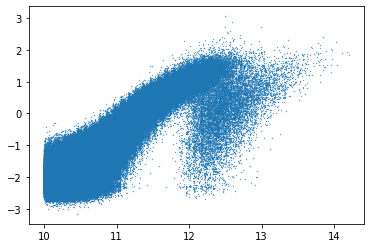

In [28]:
plt.scatter(np.concatenate(mhalo_binned), np.concatenate(shuffled_sfrs), s=0.1)

12.045738935470581


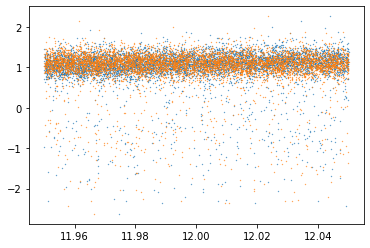

In [77]:
ibin=40
print(mhalo_binned[ibin][0])
plt.scatter(mhalo_binned[ibin], sfr_binned[ibin], s=0.1)
plt.scatter(mhalo_binned[ibin], shuffled_sfrs[ibin], s=0.1)


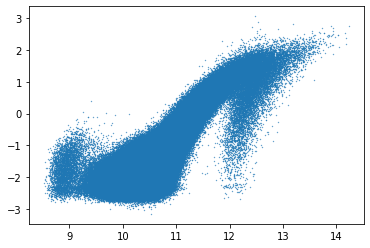

In [25]:
plt.scatter(np.concatenate(mhalo_binned), np.concatenate(sfr_binned), s=0.1)

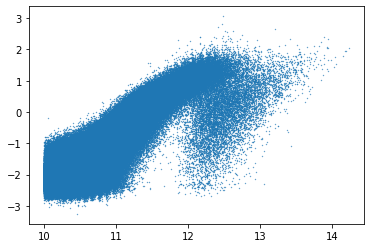

In [76]:
plt.scatter(np.concatenate(mhalo_binned), np.concatenate(shuffled_sfrs), s=0.1)

In [126]:
import MyShuffle as shuffle
import importlib
importlib.reload(shuffle)

<module 'MyShuffle' from '/cosma/home/dp004/dc-zhan5/paper1/shuffle_sfrs/MyShuffle.py'>

In [127]:
shuffle.shuffle_tng(object2shuffle="gal", ps_type="gal",snapnum=40, dp=1, do_shuffle=True, do_polyfit=False)

KeyboardInterrupt: 

In [111]:
ibin=28
cent_ihalos_in_bin = ihalo_binned[ibin]
# Find satellite galaxies corresponding to centrals in bin
mask_sat = np.isin(ihalo_tng_sat, cent_ihalos_in_bin)

sort_indices = np.argsort(cent_ihalos_in_bin)
cent_ihalos_in_bin_sorted = cent_ihalos_in_bin[sort_indices]

pos_binned_sorted = pos_binned[ibin][sort_indices]

new_pos_sat = pos_tng_sat[mask_sat] + pos_binned_sorted[np.searchsorted(cent_ihalos_in_bin_sorted, ihalo_tng_sat[mask_sat])]
# np.searchsorted returns first index in cent_ihalos_in_bin_sorted which corresponds to ihalo_tng_sat[mask_sat] 

In [87]:
print(ihalo_tng_sat[mask_sat])

[ 82815.  82815.  82815. ... 493137. 506097. 506864.]


In [120]:
mask = ihalo_binned[ibin] == ihalo_tng_sat[mask_sat][5] 

In [121]:
print(pos_binned[ibin][mask])

[[183.91656   79.386116 107.81997 ]]


In [112]:
ihalo_binned[ibin]

array([ 66305.,  82815.,  84502., ..., 508543., 517962., 525047.])

In [113]:
cent_ihalos_in_bin

array([ 66305.,  82815.,  84502., ..., 508543., 517962., 525047.])

In [83]:
ihalo_tng_sat[mask_sat][:10]

array([82815., 82815., 82815., 84502., 84502., 94706., 94706., 94706.,
       94706., 94706.])

In [81]:
new_pos_sat[:10]

array([[ 51.33592387, 126.08097782, 112.0958933 ],
       [ 51.42785807, 126.09637394, 111.7551035 ],
       [ 51.46096583, 126.15203037, 111.94684544],
       [157.29604002, 106.15475474, 167.64553639],
       [157.25229308, 105.8367692 , 167.46220204],
       [184.2734173 ,  79.49699399, 107.7639855 ],
       [184.01211054,  79.39881131, 107.71209036],
       [184.30774958,  79.36335752, 107.74607169],
       [184.0944317 ,  79.41361234, 107.8004769 ],
       [184.2749737 ,  79.40734098, 107.80185782]])

In [ ]:
#ihalo_tng_sat[mask_sat] does not return the values in order

In [67]:
len(cent_ihalos_in_bin)

74203

In [53]:
new_pos_sat

array([[179.1381362 ,  96.7204649 , 162.8253338 ],
       [179.7214034 ,  97.0524199 , 162.4891674 ],
       [179.61442404,  97.9588835 , 162.6892559 ],
       ...,
       [ 43.69077312, 195.84703087,  36.10427816],
       [ 43.27739345, 195.91172814,  35.8821102 ],
       [ 43.4466325 , 195.82669091,  35.94950445]])

In [45]:
len(ihalo_tng_sat[mask_sat])

5715

In [46]:
sorted(ihalo_tng_sat[mask_sat])

[185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 185.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 186.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,
 253.0,


In [49]:
pos_binned[ibin][-10:]

array([[ 37.885048 , 152.26361  , 163.74457  ],
       [147.556    ,  50.46777  , 140.20488  ],
       [118.81882  , 181.07126  ,  35.29604  ],
       [ 84.786835 ,  31.164791 , 175.95148  ],
       [149.71602  , 173.38991  , 136.25629  ],
       [149.07237  , 169.05717  ,  71.68958  ],
       [159.1168   , 165.82057  ,  42.020298 ],
       [  1.8287274,   9.455636 ,  29.739304 ],
       [ 43.856953 , 110.01801  , 150.53317  ],
       [ 43.508484 , 195.88501  ,  36.073505 ]])

In [44]:
sorted(cent_ihalos_in_bin)

[185.0,
 186.0,
 253.0,
 270.0,
 295.0,
 313.0,
 322.0,
 350.0,
 352.0,
 361.0,
 365.0,
 366.0,
 409.0,
 410.0,
 411.0,
 413.0,
 424.0,
 440.0,
 454.0,
 460.0,
 463.0,
 474.0,
 479.0,
 483.0,
 485.0,
 488.0,
 511.0,
 519.0,
 521.0,
 524.0,
 526.0,
 530.0,
 540.0,
 541.0,
 542.0,
 551.0,
 560.0,
 561.0,
 564.0,
 568.0,
 579.0,
 595.0,
 600.0,
 608.0,
 609.0,
 613.0,
 618.0,
 629.0,
 639.0,
 641.0,
 644.0,
 649.0,
 654.0,
 656.0,
 658.0,
 666.0,
 679.0,
 683.0,
 688.0,
 691.0,
 696.0,
 698.0,
 711.0,
 720.0,
 722.0,
 724.0,
 730.0,
 731.0,
 733.0,
 738.0,
 741.0,
 743.0,
 750.0,
 754.0,
 756.0,
 759.0,
 776.0,
 777.0,
 778.0,
 780.0,
 782.0,
 786.0,
 791.0,
 792.0,
 796.0,
 797.0,
 799.0,
 803.0,
 804.0,
 815.0,
 819.0,
 820.0,
 821.0,
 822.0,
 825.0,
 826.0,
 828.0,
 831.0,
 832.0,
 836.0,
 837.0,
 839.0,
 850.0,
 852.0,
 856.0,
 861.0,
 864.0,
 868.0,
 870.0,
 874.0,
 875.0,
 876.0,
 885.0,
 886.0,
 889.0,
 890.0,
 891.0,
 897.0,
 898.0,
 899.0,
 900.0,
 905.0,
 906.0,
 907.0,
 911.0,


In [31]:
print(cent_ihalos_in_bin)

[  320870.   342405.   356643. ...  3321289.  6936140. 12592743.]


In [25]:
print(ihalo_binned[ibin])

[  320870.   342405.   356643. ...  3321289.  6936140. 12592743.]


In [27]:
print(pos_binned[ibin][:20])

[[172.57085  198.42647   40.496063]
 [100.673775  26.430122  14.133781]
 [110.77939    9.475342  46.700306]
 ...
 [146.97305   13.095281 146.82631 ]
 [149.20921  105.77259   17.264254]
 [143.4243   185.78745   33.67883 ]]


In [28]:
print(new_pos_sat[:20])

[[172.50569497 198.46724148  40.62359596]
 [172.59270822 198.32289334  40.49447609]
 [173.46729391 101.88454438   6.64290856]
 [173.57710379 101.95823289   6.70399712]
 [173.44133108 101.98156739   6.62600945]
 [173.48264425 101.86442185   6.63439416]
 [191.24423678  34.48907807 147.69872613]
 [191.45750125  34.36030152 147.75477166]
 [190.33233399 111.50881076 203.85319409]
 [ 51.48662895 113.84579845 196.07541311]
 [191.63047197  90.75142242 145.21226372]
 [ 20.8856846  175.48279935  23.08543813]
 [ 20.99197732 175.52275448  22.95386731]
 [103.29319612 197.71638846 143.85582104]
 [181.62520683   2.17206578  60.03104438]
 [108.09245148 197.8553449  177.66817896]
 [204.21331318 115.69285738 203.09121794]
 [  3.59098286 199.7039744  112.56479271]
 [ 31.86215248  50.91988921  93.01144401]
 [ 67.76801488   4.10017063 183.74428968]]


Adding satellites so that they get moved along with their original central galaxy, keeping the same distance as before.

In [16]:


new_sat_pos = np.full_like(pos_tng_sat, -np.inf)
new_sat_sfr = np.full_like(sfr_tng_sat, -np.inf)
new_sat_mhalo = np.full_like(mhalo_tng_sat,-np.inf)
index_prev = 0
for ibin in range(len(mhalo_binned)):
    if len(sfr_binned[ibin]) > 0:
        # Find indices of satellites corresponding to the central galaxies in this bin
        mask_sat = np.isin(ihalo_tng_sat, shuffled_ihalo[ibin])
        # count the number of satellites in each halo
        counts = list(Counter(ihalo_tng_sat[mask_sat]).values())
        
        unique_values, indices = np.unique(ihalo_tng_sat[mask_sat], return_index=True)
        print(unique_values)
        print(indices)
        unique_values_in_order = unique_values[np.argsort(indices)]
        print(unique_values_in_order)
       
        # Find indices of central galaxies with at least one satellite
        mask_cent1 = np.isin(shuffled_ihalo[ibin], unique_values_in_order, assume_unique=True)
        
        sorted_unique_values = np.argsort(unique_values_in_order)
        if np.any(np.diff(sorted_unique_values) < 0):
            #raise error
            print("bad")
            
        sorted_shuffled_ihalo = np.argsort(shuffled_ihalo[ibin][mask_cent1])
        #print(len(sorted_shuffled_ihalo))
        #print(len(mask_cent1))
        #print(len(pos_binned[ibin]))
        pos_cent = pos_binned[ibin][mask_cent1][sorted_shuffled_ihalo]
        
        # repeat positions of central galaxies where there is more than one satellite
            # so that we can easily add the positions of satellite galaxies to them
        repeated_pos_cent = np.repeat(pos_cent, counts, axis=0)
        
        n_sat_in_bin = np.sum(mask_sat)

        if n_sat_in_bin > 0:

            index_next = index_prev+n_sat_in_bin
            pos_sat1 = pos_tng_sat[mask_sat] + repeated_pos_cent
            mask_high = pos_sat1 > boxsize
            mask_low = pos_sat1 < 0
            pos_sat1[mask_high] = pos_sat1[mask_high] - boxsize
            pos_sat1[mask_low] = pos_sat1[mask_low] + boxsize
            
            new_sat_pos[index_prev:index_next] = pos_sat1
            new_sat_sfr[index_prev:index_next] = sfr_tng_sat[mask_sat]
            new_sat_mhalo[index_prev:index_next] = mhalo_tng_sat[mask_sat]
    
            index_prev = index_next
            
            
        

[ 258585.  305055.  341061. ... 2104435. 2130976. 2260852.]
[   0    2    6 ... 1686 1687 1688]
[ 258585.  305055.  341061. ... 2104435. 2130976. 2260852.]
[ 198442.  232899.  256250. ... 1933662. 2001077. 2036192.]
[   0    3    7 ... 4890 4891 4892]
[ 198442.  232899.  256250. ... 1933662. 2001077. 2036192.]
[ 214134.  232555.  233917. ... 1594608. 1597068. 1643536.]
[   0    3    4 ... 7251 7252 7253]
[ 214134.  232555.  233917. ... 1594608. 1597068. 1643536.]
[ 166164.  176946.  187947. ... 1311104. 1340938. 1358302.]
[    0     6     9 ... 10428 10429 10430]
[ 166164.  176946.  187947. ... 1311104. 1340938. 1358302.]
[ 147712.  174154.  174230. ... 1090916. 1102194. 1110515.]
[    0     4     6 ... 13720 13721 13722]
[ 147712.  174154.  174230. ... 1090916. 1102194. 1110515.]
[113480. 117317. 134728. ... 904057. 906330. 932016.]
[    0     5     8 ... 17265 17266 17267]
[113480. 117317. 134728. ... 904057. 906330. 932016.]
[ 74795.  93084. 105219. ... 747884. 751902. 752524.]
[   

### Write to file

In [134]:

#f_group = open(f"shuffled_data/snap{snapnum}/sfr-gal-shuffled_logM10_all_seed{seed}_logSFR<2.txt", "w")
f_group = open(f"../shuffled_data/snap{snapnum}/sfr-cent_logM10_polyfit0.1.txt", "w")
#f_group = open(f"../shuffled_data/snap{snapnum}/sfr-cent_logM10_0.1.txt", "w")



print("# log10(mass[Msun/h]) x[Mpc/h] y[Mpc/h] z[Mpc/h] log10(sfr[Msun/yr])", file=f_group)
# Print shuffled halos
for ibin in range(len(mhalo_binned)):
    if len(sfr_binned[ibin]) > 0:
        for ihalo in range(len(sfr_binned[ibin])):
            if shuffled_sfrs[ibin][ihalo] > -5:
                print(mhalo_binned[ibin][ihalo], pos_binned[ibin][ihalo][0], pos_binned[ibin][ihalo][1], pos_binned[ibin][ihalo][2], shuffled_sfrs[ibin][ihalo], file=f_group)
"""
for i in range(len(mhalo_tng_sat)):
    if (new_sat_mhalo[i] > 9) :
        print(new_sat_mhalo[i], new_sat_pos[i][0], new_sat_pos[i][1], new_sat_pos[i][2], new_sat_sfr[i], file = f_group)
"""
# Print unshuffled halos
"""
mhalo_tng_min = mhalo_tng3[~mask_min3]
pos_tng_min = pos_tng3[~mask_min3]
sfr_tng_min = sfr_tng3[~mask_min3]
for i in range(len(mhalo_tng_min)):
    if sfr_tng_min[i] > -5:
        print(mhalo_tng_min[i], pos_tng_min[i][0],pos_tng_min[i][1],pos_tng_min[i][2], sfr_tng_min[i], file = f_group)



mask_min_sat = np.isin(ihalo_tng_sat, ihalo_tng_sum, invert=True)
mhalo_tng_sat_min = mhalo_tng_sat2[~mask_min_sat]
pos_tng_sat_min = pos_tng_sat2[~mask_min_sat]
sfr_tng_sat_min = sfr_tng_sat2[~mask_min_sat]
for i in range(len(mhalo_tng_sat_min)):
    if sfr_tng_sat_min[i] > -5:
        print(mhalo_tng_sat_min[i], pos_tng_sat_min[i][0],pos_tng_sat_min[i][1],pos_tng_sat_min[i][2], sfr_tng_sat_min[i], file = f_group)
"""
        
f_group.close()

In [21]:
mhalo_binned[25]

array([10.45000005, 10.45000106, 10.4500021 , ..., 10.54999667,
       10.549999  , 10.54999942])

### Test to see we get same as original without shuffling

In [279]:

f_group = open(f"shuffled_data/sfr-gal-shuffled_logM10_all_seed{seed}_dlogM1dp_test_bc.txt", "w")

print("# log10(mass[Msun/h]) x[Mpc/h] y[Mpc/h] z[Mpc/h] log10(sfr[Msun/yr])", file=f_group)
# Print shuffled halos
for ibin in range(len(mhalo_binned)):
    if len(sfr_binned[ibin]) > 0:
        for ihalo in range(len(sfr_binned[ibin])):
            if shuffled_sfrs[ibin][ihalo] > -5:
                print(mhalo_binned[ibin][ihalo], pos_binned[ibin][ihalo][0], pos_binned[ibin][ihalo][1], pos_binned[ibin][ihalo][2], shuffled_sfrs[ibin][ihalo], file=f_group)

# Print unshuffled halos
mhalo_tng_min = mhalo_tng3[~mask_min3]
pos_tng_min = pos_tng3[~mask_min3]
sfr_tng_min = sfr_tng3[~mask_min3]
for i in range(len(mhalo_tng_min)):
    if sfr_tng_min[i] > -5:
        print(mhalo_tng_min[i], pos_tng_min[i][0],pos_tng_min[i][1],pos_tng_min[i][2], sfr_tng_min[i], file = f_group)

for i in range(len(mhalo_tng_sat)):
    print(new_sat_mhalo[i], new_sat_pos[i][0], new_sat_pos[i][1], new_sat_pos[i][2], new_sat_sfr[i], file = f_group)
f_group.close()

### Loop through seeds

In [311]:

shuffle = True
polyfit = False
group = True

count_cent = 0
count_sat = 0
for seed in range(0,1):
    random.seed(seed)

    shuffled_sfrs = []
    shuffled_ihalo = []

    polyfit_list = []

    for ibin in range(len(mhalo_binned)):
        if len(sfr_binned[ibin]) > 0:
            indices = np.arange(0,len(sfr_binned[ibin]),1) 
           
            random.shuffle(indices)
            mask = np.isinf(sfr_binned[ibin]) == False # Only do polyfit for non zero SFRs
            if (np.sum(mask) > 0) and len(sfr_binned[ibin]) > 1:
                a, b = np.polyfit(mhalo_binned[ibin][mask], sfr_binned[ibin][mask], 1) # Find line of best fit in bin
                polyfit_list.append((a,b))
                #print(a,b)
                sfr_diff = np.array(sfr_binned[ibin] - (a*mhalo_binned[ibin]  + b)) # Compute difference between SFR and line of best fit for each galaxy
               
                if shuffle is True:
                    if polyfit is True:
                        shuffled_sfrs.append(sfr_diff[indices]+ (a*mhalo_binned[ibin]  + b)) # shuffle the differences, then add difference on to best fit value for given halo mass
                        shuffled_ihalo.append(np.array(ihalo_binned[ibin])[indices])
                    else:
                        shuffled_sfrs.append(np.array(sfr_binned[ibin])[indices]) 
                        shuffled_ihalo.append(np.array(ihalo_binned[ibin])[indices])
                else:
                    shuffled_sfrs.append(np.array(sfr_binned[ibin]))
                    shuffled_ihalo.append(np.array(ihalo_binned[ibin]))
            else:
                shuffled_sfrs.append(np.array(sfr_binned[ibin]))
                shuffled_ihalo.append(np.array(ihalo_binned[ibin]))   
        else:
            shuffled_sfrs.append([])
            shuffled_ihalo.append([])
            polyfit_list.append(None)
           
    if group is False:
        new_sat_pos = np.empty_like(pos_tng_sat)
        new_sat_sfr = np.empty_like(sfr_tng_sat)
        new_sat_mhalo = np.empty_like(mhalo_tng_sat)
        index_prev = 0
        for ibin in range(len(mhalo_binned)):
            if len(sfr_binned[ibin]) > 0:
                # Find indices of satellites corresponding to the central galaxies in this bin
                mask_sat = np.isin(ihalo_tng_sat, shuffled_ihalo[ibin])
                # count the number of satellites in each halo
                counts = list(Counter(ihalo_tng_sat[mask_sat]).values())

                unique_values, indices1 = np.unique(ihalo_tng_sat[mask_sat], return_index=True)
                unique_values_in_order = unique_values[np.argsort(indices1)]

                # Find indices of central galaxies with at least one satellite
                mask_cent1 = np.isin(shuffled_ihalo[ibin], unique_values_in_order, assume_unique=True)

                sorted_unique_values = np.argsort(unique_values_in_order)
                if np.any(np.diff(sorted_unique_values) < 0):
                    #raise error
                    print("bad")

                sorted_shuffled_ihalo = np.argsort(shuffled_ihalo[ibin][mask_cent1])
                pos_cent = pos_binned[ibin][mask_cent1][sorted_shuffled_ihalo]

                # repeat positions of central galaxies where there is more than one satellite
                    # so that we can easily add the positions of satellite galaxies to them
                repeated_pos_cent = np.repeat(pos_cent, counts, axis=0)

                n_sat_in_bin = np.sum(mask_sat)


                if n_sat_in_bin > 0:

                    index_next = index_prev+n_sat_in_bin
                    new_sat_pos[index_prev:index_next] = pos_tng_sat[mask_sat] + repeated_pos_cent
                    new_sat_sfr[index_prev:index_next] = sfr_tng_sat[mask_sat]
                    new_sat_mhalo[index_prev:index_next] = mhalo_tng_sat[mask_sat]

                    index_prev = index_next


        print(index_next)
    #print(len(mhalo_tng_sat))

    #odir = "/snap7/scratch/dp004/dc-zhan5/shuffled"
    #odir = "./"
    odir = "/cosma8/data/dp004/dc-zhan5/shuffled"
    #f_group = open(f"{odir}/sfr-gal-logM10_dlogM0.1_snap40/slice30/islice0/seed{seed}.txt", "w")
    f_group = open(f"{odir}/logM10_dlogM0.1_snap40/group/nonzero/seed{seed}.txt", "w")

    
    print("# log10(mass[Msun/h]) x[Mpc/h] y[Mpc/h] z[Mpc/h] log10(sfr[Msun/yr])", file=f_group)
    # Print shuffled halos
    
    for ibin in range(len(mhalo_binned)):
        if len(sfr_binned[ibin]) > 0:
            for ihalo in range(len(sfr_binned[ibin])):
                if shuffled_sfrs[ibin][ihalo] > -5:
                    print(mhalo_binned[ibin][ihalo], pos_binned[ibin][ihalo][0], pos_binned[ibin][ihalo][1], pos_binned[ibin][ihalo][2], shuffled_sfrs[ibin][ihalo], file=f_group)
                    count_cent += 1
    

    if group is False:
        for i in range(index_next):
            #if (new_sat_mhalo[i] > 10) :
            print(new_sat_mhalo[i], new_sat_pos[i][0], new_sat_pos[i][1], new_sat_pos[i][2], new_sat_sfr[i], file = f_group)
            count_sat += 1
    """

    # Print unshuffled halos
    mhalo_tng_min = mhalo_tng3[~mask_min3]
    pos_tng_min = pos_tng3[~mask_min3]
    sfr_tng_min = sfr_tng3[~mask_min3]
    for i in range(len(mhalo_tng_min)):
        if sfr_tng_min[i] > -5:
            print(mhalo_tng_min[i], pos_tng_min[i][0],pos_tng_min[i][1],pos_tng_min[i][2], sfr_tng_min[i], file = f_group)
    """
    f_group.close()

In [53]:
print(len(sfr_tng1))

1061090


In [49]:
print(len(sfr_tng_sat))

524977


In [52]:
print(count_cent)
print(count_sat)

1061090
523942


In [55]:
print(count_cent)
print(count_sat)

1061090
523942


In [168]:
len(set(ihalo_tng_sat))

286891

In [169]:
len(set(new_sat_mhalo))

284346

In [137]:
unique_values = np.isin(ihalo_tng_sat, ihalo_tng1)

In [148]:
not_in = np.isin(ihalo_tng_sat, ihalo_tng3, invert=True)

In [147]:
np.sum(unique_values)

1035

In [150]:
print(ihalo_tng_sat[not_in])

[3.370000e+02 3.370000e+02 3.370000e+02 ... 1.515745e+06 1.606314e+06
 1.774451e+06]


In [170]:
mask_sat = np.isin(ihalo_tng_sat, ihalo_tng3)

In [171]:
print(np.sum(mask_sat))

523936


In [185]:
count = 0
for ibin in range(len(ihalo_binned)):
    #mask_sat = np.isin(ihalo_tng_sat, shuffled_ihalo[ibin])
    mask_sat = np.isin(ihalo_tng_sat, ihalo_binned[ibin])
    
    #count += len(ihalo_binned[ibin])
    count += np.sum(mask_sat)

In [ ]:
mask_sat = np.isin(ihalo_tng_sat, ihalo

In [99]:
len(ihalo_tng3)

1945442

In [186]:
print(count)

524977


In [414]:
plt.plot(mhalo_bins, medians)

NameError: name 'medians' is not defined

### Invented relation

In [255]:
a1 = 1.85
b1 = -21
y = a1*11.95 + b1
print(y)
a2 = 0.43
b2 = y - a2*11.95
print(b2)
y = a2*11.95 + b2
print(y)

1.1074999999999982
-4.0310000000000015
1.1074999999999982


In [256]:
poly_low = np.poly1d((a1,b1))
poly_high = np.poly1d((a2,b2))

In [412]:
import os
shuffle = False
polyfit = False

seed = 0

sigma = 0.2
sigma_low=1
sigma_high =5

#odir = f"/cosma8/data/dp004/dc-zhan5/invented/2sigma/{sigma_low}_{sigma_high}"
odir = f"/cosma8/data/dp004/dc-zhan5/invented/sigma{sigma}"
#os.makedirs(odir)

is_mean = True

for fiducial_seed in range(0,1):
    
    random.seed(seed)

    shuffled_sfrs = []
    shuffled_ihalo = []

    polyfit_list = []
  
    new_sfrs = []
    new_means = []

    for ibin in range(len(mhalo_binned)):
        if len(sfr_binned[ibin]) > 0:
            indices = np.arange(0,len(sfr_binned[ibin]),1) 
           
            random.shuffle(indices)
            mask = np.isinf(sfr_binned[ibin]) == False # Only do polyfit for non zero SFRs
            if (np.sum(mask) != 0) and len(sfr_binned[ibin]) > 1:
                a, b = np.polyfit(mhalo_binned[ibin][mask], sfr_binned[ibin][mask], 1) # Find line of best fit in bin
                #polyfit_list.append((a,b))
                polyfit_list.append(a*mhalo_binned[ibin]+b)
                #print(a,b)
                if mhalo_bins[ibin] >= 12:
                    poly = poly_high
                    sigma = sigma_high
                   
                else:
                    poly = poly_low
                    sigma = sigma_low
                    
                
                
                np.random.seed(fiducial_seed)
                sfr_orig = np.random.normal(poly(mhalo_binned[ibin]), sigma)
                sfr_diff = np.array(sfr_orig - poly(mhalo_binned[ibin])) # Compute difference between SFR and line of best fit for each galaxy
                
                new_sfrs.append(sfr_orig)
                
                #print(np.mean(poly(mhalo_binned[ibin])))
                
                
                #mean = np.log10(np.mean(10**sfr_orig))
                new_means.append(mean)
                    
                if shuffle is True:
                    if polyfit is True:
                        shuffled_sfrs.append(sfr_diff[indices]+ poly(mhalo_binned[ibin])) # shuffle the differences, then add difference on to best fit value for given halo mass
                        shuffled_ihalo.append(np.array(ihalo_binned[ibin])[indices])
                    else:
                        shuffled_sfrs.append(np.array(sfr_orig)[indices]) 
                        shuffled_ihalo.append(np.array(ihalo_binned[ibin])[indices])
                else:
                    shuffled_sfrs.append(np.array(sfr_orig))
                    shuffled_ihalo.append(np.array(ihalo_binned[ibin]))
            else:
                shuffled_sfrs.append(np.array(sfr_binned[ibin]))
                shuffled_ihalo.append(np.array(ihalo_binned[ibin]))   
                polyfit_list.append(sfr_binned[ibin])
                new_means.append(sfr_binned[ibin][0])
        else:
            shuffled_sfrs.append([])
            shuffled_ihalo.append([])
            new_means.append([])
            polyfit_list.append([])
    """
    new_sat_pos = np.empty_like(pos_tng_sat)
    new_sat_sfr = np.empty_like(sfr_tng_sat)
    new_sat_mhalo = np.empty_like(mhalo_tng_sat)
    index_prev = 0
    for ibin in range(len(mhalo_binned)):
        if len(sfr_binned[ibin]) > 0:
            # Find indices of satellites corresponding to the central galaxies in this bin
            mask_sat = np.isin(ihalo_tng_sat, shuffled_ihalo[ibin])
            # count the number of satellites in each halo
            counts = list(Counter(ihalo_tng_sat[mask_sat]).values())

            unique_values, indices1 = np.unique(ihalo_tng_sat[mask_sat], return_index=True)
            unique_values_in_order = unique_values[np.argsort(indices1)]

            # Find indices of central galaxies with at least one satellite
            mask_cent1 = np.isin(shuffled_ihalo[ibin], unique_values_in_order, assume_unique=True)

            sorted_unique_values = np.argsort(unique_values_in_order)
            if np.any(np.diff(sorted_unique_values) < 0):
                #raise error
                print("bad")

            sorted_shuffled_ihalo = np.argsort(shuffled_ihalo[ibin][mask_cent1])
            pos_cent = pos_binned[ibin][mask_cent1][sorted_shuffled_ihalo]

            # repeat positions of central galaxies where there is more than one satellite
                # so that we can easily add the positions of satellite galaxies to them
            repeated_pos_cent = np.repeat(pos_cent, counts, axis=0)

            n_sat_in_bin = np.sum(mask_sat)

            if n_sat_in_bin > 0:

                index_next = index_prev+n_sat_in_bin
                new_sat_pos[index_prev:index_next] = pos_tng_sat[mask_sat] + repeated_pos_cent
                new_sat_sfr[index_prev:index_next] = sfr_tng_sat[mask_sat]
                new_sat_mhalo[index_prev:index_next] = mhalo_tng_sat[mask_sat]

                index_prev = index_next

    """
        

    #odir = "/snap7/scratch/dp004/dc-zhan5/shuffled"
    #odir = "./"
    
    #f_group = open(f"{odir}/sfr-gal-logM10_dlogM0.1_snap40/invented/initial{fiducial_seed}/seed{seed}_test.txt", "w")

    f_group = open(f"{odir}/seed{fiducial_seed}_mean.txt", "w")
    
    #

    print("# log10(mass[Msun/h]) x[Mpc/h] y[Mpc/h] z[Mpc/h] log10(sfr[Msun/yr])", file=f_group)
    # Print shuffled halos
    for ibin in range(len(mhalo_binned)):
        if len(sfr_binned[ibin]) > 0:
            for ihalo in range(len(sfr_binned[ibin])):
                if shuffled_sfrs[ibin][ihalo] > -5:
                    if is_mean:
                        print(mhalo_binned[ibin][ihalo], pos_binned[ibin][ihalo][0], pos_binned[ibin][ihalo][1], pos_binned[ibin][ihalo][2], new_means[ibin], file=f_group)
                    
                    else:
                        print(mhalo_binned[ibin][ihalo], pos_binned[ibin][ihalo][0], pos_binned[ibin][ihalo][1], pos_binned[ibin][ihalo][2], shuffled_sfrs[ibin][ihalo], file=f_group)
                    
    
    """
    for i in range(index_next):
        if (new_sat_mhalo[i] > 9) :
            print(new_sat_mhalo[i], new_sat_pos[i][0], new_sat_pos[i][1], new_sat_pos[i][2], new_sat_sfr[i], file = f_group)
    """
   
    # # Print unshuffled halos
    # mhalo_tng_min = mhalo_tng3[~mask_min3]
    # pos_tng_min = pos_tng3[~mask_min3]
    # sfr_tng_min = sfr_tng3[~mask_min3]
    # for i in range(len(mhalo_tng_min)):
    #     if sfr_tng_min[i] > -5:
    #         print(mhalo_tng_min[i], pos_tng_min[i][0],pos_tng_min[i][1],pos_tng_min[i][2], sfr_tng_min[i], file = f_group)

    f_group.close()

In [356]:
shuffled_sfrs[23]

array([0.01614091, 0.01165269, 0.01537582, ..., 0.01086718, 0.00938773,
       0.00955358])

In [357]:
mhalo_binned[23]

array([10.3117249 , 10.28810254, 10.32929665, ..., 10.25052544,
       10.26129964, 10.27982032])

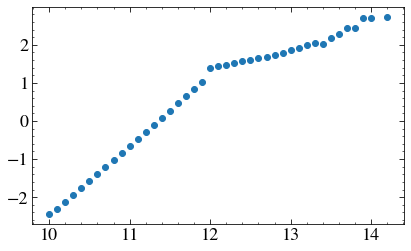

In [375]:
plt.scatter(mhalo_bins, new_means)

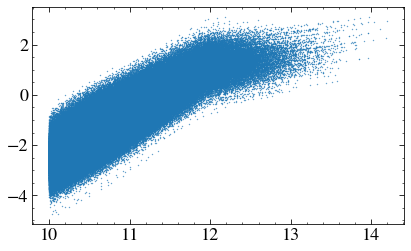

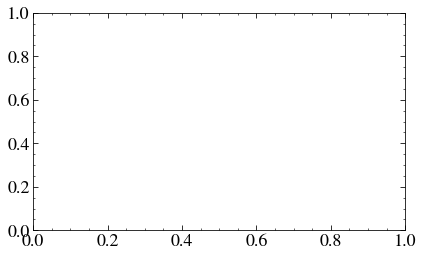

In [384]:
plt.scatter(np.concatenate(mhalo_binned),np.concatenate(shuffled_sfrs), s=0.1)
plt.show()
plt.cla()

IndexError: index 70 is out of bounds for axis 0 with size 70

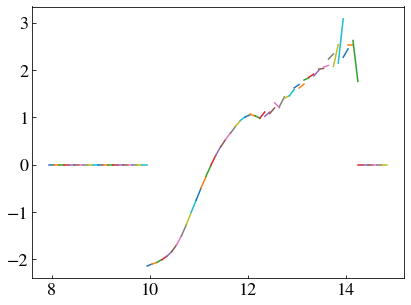

In [110]:
for ibin in range(len(mhalo_bins)):
    x = [mhalo_edges[ibin], mhalo_edges[ibin+1]]
    f = np.poly1d(polyfit_list[ibin])
    y = f(x)
    plt.plot(x,y)

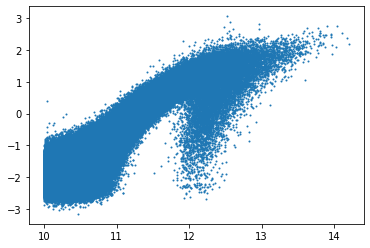

In [71]:
ibin = 40
plt.scatter(np.concatenate(mhalo_binned), np.concatenate(sfr_binned),s=1)
plt.scatter(np.concatenate(mhalo_binned), np.concatenate(polyfit_list),s=0.1, label="Best fit line")

[  1.8536379  -21.05589134]
[-2.51951235  1.18776345]
[ 0.43261632 -4.08316183]
[1.10823398 1.97346661]


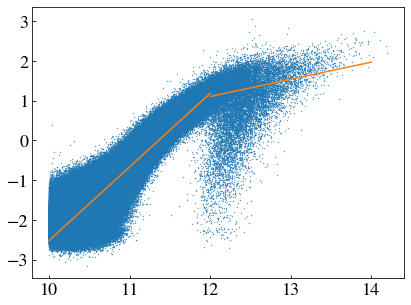

In [142]:
plt.scatter(mhalo_tng3,sfr_tng3, s=0.1)
mask_low = (mhalo_tng3 < 12) & (sfr_tng3>-5)
poly = np.polyfit(mhalo_tng3[mask_low], sfr_tng3[mask_low], 1) 
print(poly)
f = np.poly1d(poly)
x = [10,12]
y = f(x)
print(y)
plt.plot(x,y, c=color_list[1])

mask_low = (mhalo_tng3 > 12) & (sfr_tng3>0)
poly = np.polyfit(mhalo_tng3[mask_low], sfr_tng3[mask_low], 1) 
print(poly)
f = np.poly1d(poly)
x = [12,14]
y = f(x)
print(y)
plt.plot(x,y, c=color_list[1])

In [269]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2
from matplotlib.lines import Line2D

In [267]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list = palette_tab10

[  1.81493931 -20.6711927 ]
[-2.5     1.1075]
[-0.11240668  2.43139057]
[1.1075 1.989 ]


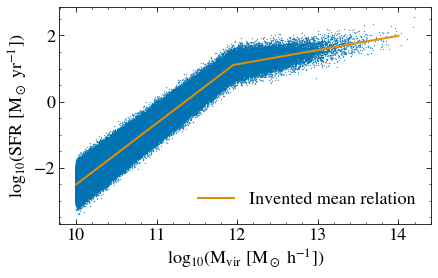

In [275]:
#plt.scatter(mhalo_tng3,sfr_tng3, s=0.1)
plt.scatter(np.concatenate(mhalo_binned), np.concatenate(shuffled_sfrs),s=0.1, color=color_list[0])
mask_low = (mhalo_tng3 < 11.95) & (sfr_tng3>-5)
poly = np.polyfit(mhalo_tng3[mask_low], sfr_tng3[mask_low], 1) 
print(poly)
f = np.poly1d((a1,b1))
x = [10,11.95]
y = f(x)
print(y)
plt.plot(x,y, c=color_list[1])

mask_low = (mhalo_tng3 > 11.95) & (sfr_tng3>0)
poly = np.polyfit(mhalo_tng3[mask_low], sfr_tng3[mask_low], 1) 
print(poly)
f = np.poly1d((a2,b2))
x = [11.95,14]
y = f(x)
print(y)
plt.plot(x,y, c=color_list[1])
solid_line = Line2D([],[],color=color_list[1], linestyle="solid", label="Invented mean relation")

plt.xlabel('log$_{10}$(M$_\mathrm{vir}$ [M$_\odot$ h$^{-1}$])')
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.legend(handles =[solid_line])
#plt.savefig("../figures2/invented_relation_scatter_0.2.png", format="png", dpi=300, bbox_inches="tight")
plt.clf()

In [76]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 5)
plt.rcParams["legend.frameon"] = False

Text(0, 0.5, 'log$_{10}$(SFR [M$_\\odot$ yr$^{-1}$])')

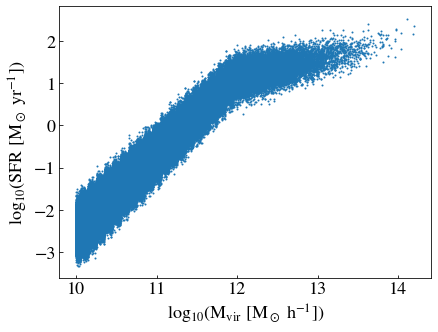

In [184]:
from matplotlib.lines import Line2D
color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.scatter(np.concatenate(mhalo_binned), np.concatenate(shuffled_sfrs),s=1)
#plt.scatter(np.concatenate(mhalo_binned), np.concatenate(polyfit_list),s=1)

solid_line = Line2D([],[],color=color_list[1], linestyle="solid", label="Best fit line")

plt.xlabel('log$_{10}$(M$_\mathrm{vir}$ [M$_\odot$ h$^{-1}$])')
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
#plt.legend(handles =[solid_line])
#plt.savefig("../figures2/sfr_mvir_polyfit_sigma0.5.pdf", format="pdf", bbox_inches="tight")

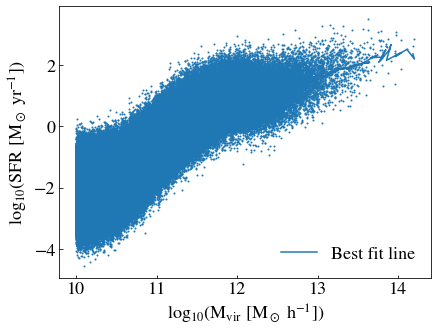

In [93]:
ibin = 40
plt.scatter(np.concatenate(mhalo_binned), np.concatenate(shuffled_sfrs),s=1)
plt.plot(np.concatenate(mhalo_binned), np.concatenate(polyfit_list), label="Best fit line")

plt.xlabel('log$_{10}$(M$_\mathrm{vir}$ [M$_\odot$ h$^{-1}$])')
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.legend()
#plt.savefig("../figures2/sfr_mvir_polyfit_sigma0.5.pdf", format="pdf", bbox_inches="tight")

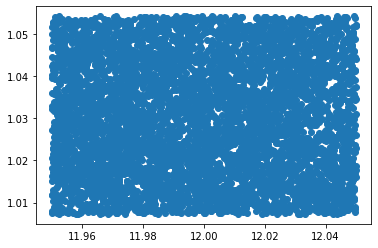

In [50]:
ibin = 40
plt.scatter(mhalo_binned[ibin], shuffled_sfrs[ibin])

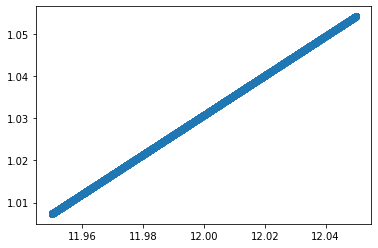

In [51]:
ibin = 40
plt.scatter(mhalo_binned[ibin], sfr_binned[ibin])

In [21]:
new_sat_mhalo

array([10.03750882, 10.01767318, 10.02153064, ..., 14.15249205,
       14.15249205, 14.15249205])

### Plot for number of halos in each bin

In [ ]:
mhalo_bins = [min(mhalo_tng)]
counts_binned = [0]
index = 0
for mhalo in mhalo_tng:
    if mhalo == mhalo_bins[-1]:
        counts_binned[index] += 1
    else:
        mhalo_bins.append(mhalo)
        index += 1
        counts_binned.append(1)

Text(0, 0.5, 'N$_{\\rm halos}$ in bin')

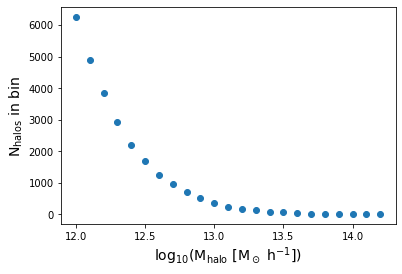

In [ ]:
fontsize=14
plt.scatter(mhalo_bins,counts_binned)
plt.xlabel('log$_{10}$(M$_\mathrm{halo}$ [M$_\odot$ h$^{-1}$])', fontsize=fontsize)
plt.ylabel(r'N$_{\rm halos}$ in bin', fontsize=fontsize)